# Problema 1

In [129]:
Clear["Global`*"]
WolframColor = RGBColor[0.941, 0.502, 0.0];

In [131]:
g = 9.8;
Ep[m_,g_,h_] := m*g*h;
Ek[m_,v_] := 0.5*m*v^2;

## 1.a

In [134]:
m = 0.145;
h = 100;
v = 0;
Ek[m,v]

0.

## 1.b

In [138]:
Ep[m,g,h]

142.1

## 2

In [139]:
m = 5000;
h = 45*1000;

(* En el suelo Ek = 100%Ep *)

Ep[m,g,h]//TraditionalForm

FormBox["2.205`*^9", TraditionalForm]

## 3

In [143]:

(* Masa del punto 1 *)
m = 0.145;

(* Misma altura del punto 2 *)

Ep[m,g,h]//TraditionalForm

FormBox["63945.`", TraditionalForm]

## 4

## 4.a

In [148]:
Clear[v];
m = 0.145;
aSol = Solve[Ep[m,g,h]==0.5*m*v^2 && v>0, v][[1,1]];
aSol

v -> 939.149

## 4.b

In [152]:
m = 5000;
bSol = Solve[Ep[m,g,h]==0.5*m*v^2 && v>0, v][[1,1]];
bSol

v -> 939.149

## 4.c

In [155]:
(* Discusión *)

# Problema 2

In [156]:
Clear["Global`*"]
WolframColor = RGBColor[0.941, 0.502, 0.0];

## 1

In [158]:
datos = Import["datos_objetos.dat", "Table"];

In [159]:
puntos = datos[[All, {1, 2}]];  (* Coordenadas x,y *)
nombres = datos[[All, 3]];      (* Nombres *)

puntosConEtiquetas = Table[
  Callout[puntos[[i]], nombres[[i]]],
  {i, Length[puntos]}
];

-Graphics-
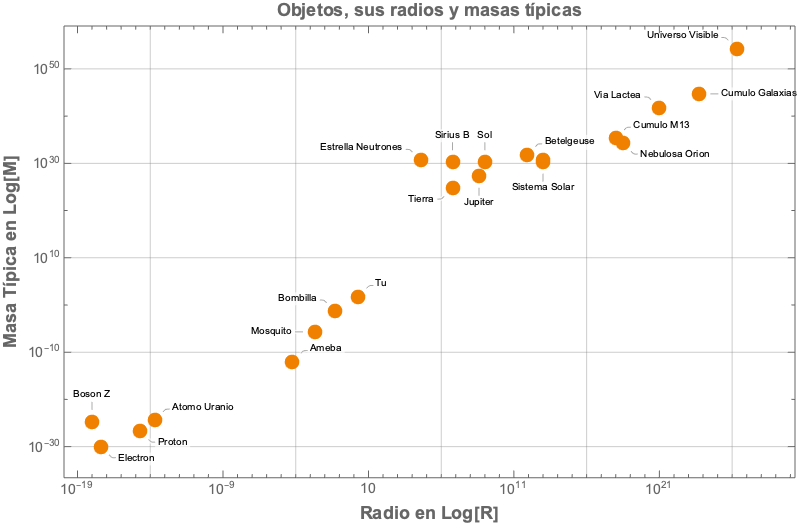

In [162]:
ListPlot[puntosConEtiquetas,
    ScalingFunctions -> {"Log", "Log"},
    
    PlotStyle -> {WolframColor, PointSize[0.02]},
    PlotLabel -> Style["Objetos, sus radios y masas típicas", 18, Bold],
    
    Frame -> True,
    FrameLabel -> {
        Style["Radio en Log[R]", 18, Bold],   
        Style["Masa Típica en Log[M]", 18, Bold]},   
    FrameTicksStyle -> Directive[14],
    
    GridLines -> Automatic,
    ImageSize->800]

## 2

In [163]:
rhoN = 4*^17; (* Materia nuclear *)
rhoW = 1000;  (* Agua *)

(* Funciones de Masa en términos de Radio: M = rho * V *)
mNuclear[r_] := rhoN * (4/3) * Pi * r^3;
mAgua[r_] := rhoW * (4/3) * Pi * r^3;

-Graphics-
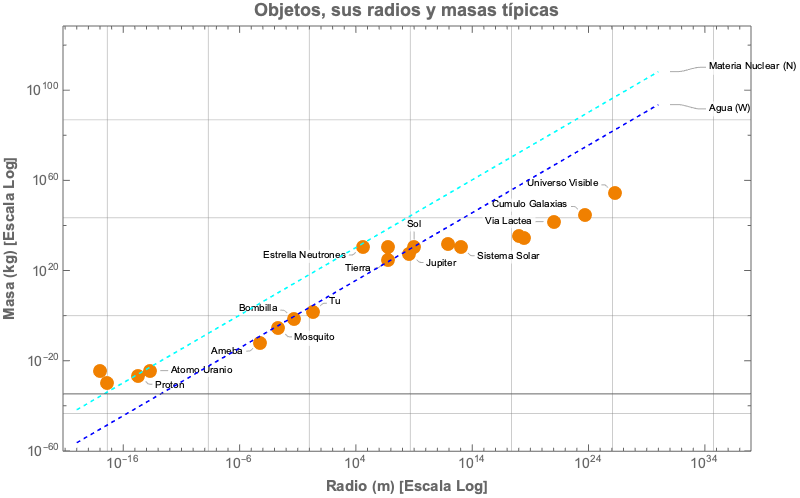

In [174]:
graficoPuntos = ListPlot[puntosConEtiquetas,
    ScalingFunctions -> {"Log", "Log"},
    PlotStyle -> {WolframColor, PointSize[0.02]}
];

lineasDensidad = Plot[{mNuclear[r], mAgua[r]}, {r, 1*^-20, 1*^30},
    ScalingFunctions -> {"Log", "Log"},
    PlotStyle -> {{Cyan, Dashed}, {Blue, Dashed}},
    PlotLabels -> {"Materia Nuclear (N)", "Agua (W)"}
];

Show[graficoPuntos, lineasDensidad,
    PlotLabel -> Style["Objetos, sus radios y masas típicas", 18, Bold],
    Frame -> True,
    FrameLabel -> {
        Style["Radio (m) [Escala Log]", 15, Bold],   
        Style["Masa (kg) [Escala Log]", 15, Bold]},   
    FrameTicksStyle -> Directive[14],
    GridLines -> Automatic,
    ImageSize -> 800,
    PlotRange -> All]


## 3

In [185]:
(* Relación R = 3M convertida a M(r) en kg y m *)
mAgujeroNegro[r_] := (2/3) * 10^27 * r;

lineasReferencia = Plot[{mNuclear[r], mAgua[r], mAgujeroNegro[r]}, 
    {r, 1*^-20, 1*^30},
    ScalingFunctions -> {"Log", "Log"},
    PlotStyle -> {{Black, Dashed}, {Blue, Dashed}, {Purple, Thick}},
    PlotLabels -> {"Materia Nuclear (N)", "Agua (W)", "Límite Agujero Negro"},
    (* Sombreado de la región prohibida *)
    Filling -> {3 -> Top}, 
    FillingStyle -> Directive[Opacity[0.4], Gray]
];

-Graphics-
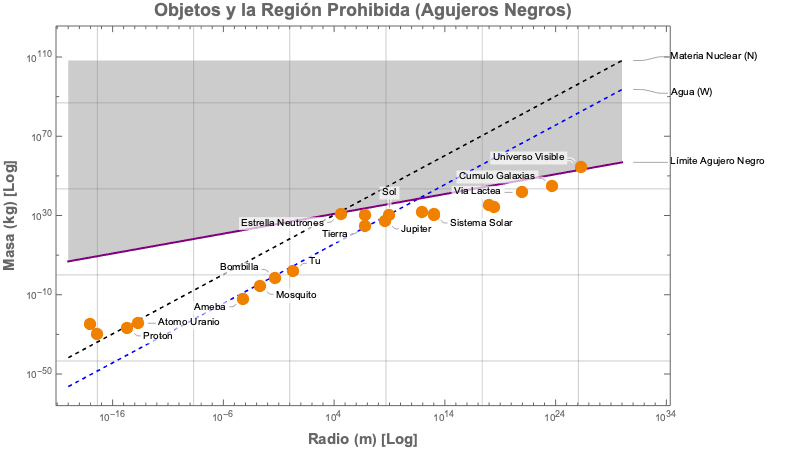

In [188]:
Show[lineasReferencia, graficoPuntos,
    PlotLabel -> Style["Objetos y la Región Prohibida (Agujeros Negros)", 18, Bold],
    Frame -> True,
    FrameLabel -> {
        Style["Radio (m) [Log]", 15, Bold],   
        Style["Masa (kg) [Log]", 15, Bold]},
    GridLines -> Automatic,
    ImageSize -> 800,
    PlotRange -> All
]

## 4

-Graphics-
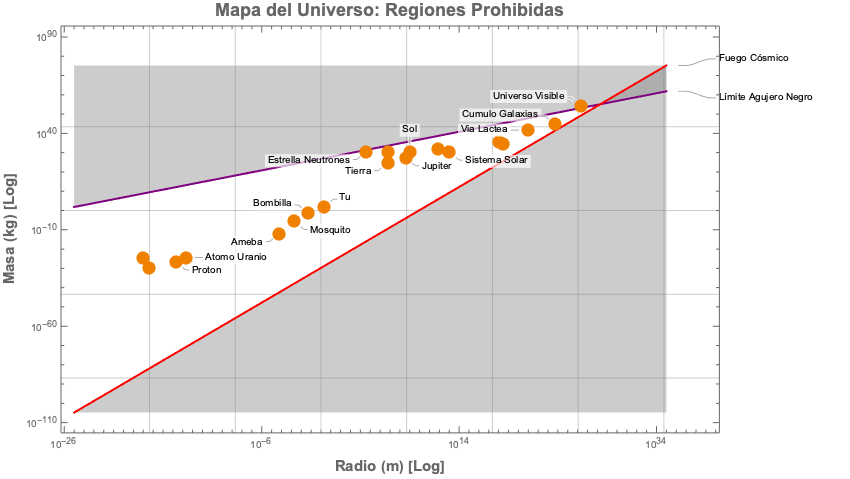

In [189]:
Clear["Global`*"]
WolframColor = RGBColor[0.941, 0.502, 0.0];


datos = Import["datos_objetos.dat", "Table"];
puntos = datos[[All, {1, 2}]]; 
nombres = datos[[All, 3]];
puntosConEtiquetas = Table[Callout[puntos[[i]], nombres[[i]]], {i, Length[puntos]}];

rhoC = 4*^-31; (* Densidad mínima *)
mRadiacion[r_] := rhoC * (4/3) * Pi * r^3;
mAgujeroNegro[r_] := (2/3) * 10^27 * r; (* Límite Agujero Negro *)

lineasYSombras = Plot[{mAgujeroNegro[r], mRadiacion[r]}, 
    {r, 1*^-25, 1*^35},
    ScalingFunctions -> {"Log", "Log"},
    PlotStyle -> {{Purple, Thick}, {Red, Thick}},
    PlotLabels -> {"Límite Agujero Negro", "Fuego Cósmico"},

    Filling -> {1 -> Top, 2 -> Bottom}, 
    FillingStyle -> {Directive[Opacity[0.4], Gray], Directive[Opacity[0.4], Gray]},
    PlotRange -> All
];

graficoPuntos = ListPlot[puntosConEtiquetas, 
    ScalingFunctions -> {"Log", "Log"}, 
    PlotStyle -> {WolframColor, PointSize[0.02]}];

Show[lineasYSombras, graficoPuntos,
    PlotLabel -> Style["Mapa del Universo: Regiones Prohibidas", 18, Bold],
    Frame -> True,
    FrameLabel -> {
        Style["Radio (m) [Log]", 15, Bold], 
        Style["Masa (kg) [Log]", 15, Bold]},
    GridLines -> Automatic,
    ImageSize -> 850
]

-Graphics-
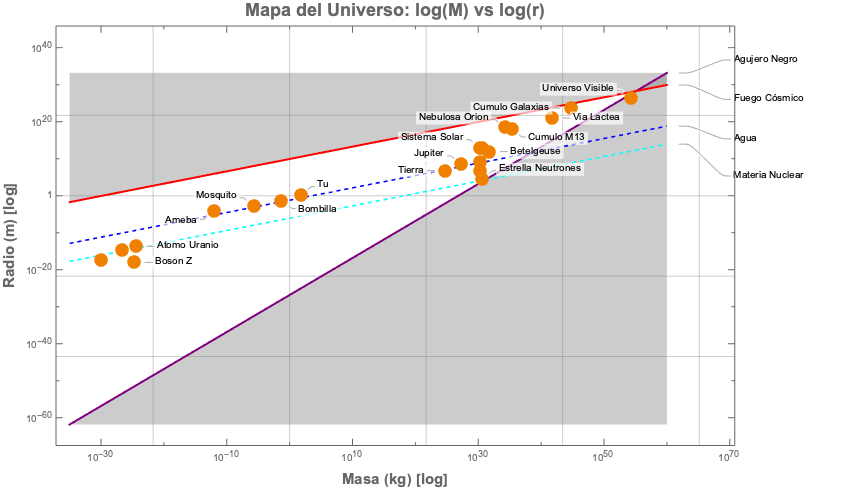

In [242]:
Clear["Global`*"]
WolframColor = RGBColor[0.941, 0.502, 0.0];

datos = Import["datos_objetos.dat", "Table"];
puntos = datos[[All, {2, 1}]]; 
nombres = datos[[All, 3]];

puntosConEtiquetas = Table[
  Callout[puntos[[i]], nombres[[i]]],
  {i, Length[puntos]}
];

rhoN = 4*^17;    (* Materia nuclear *)
rhoW = 1000;     (* Agua *)
rhoC = 4*^-31;   (* Fuego cósmico *)

(* Volumen V = M/rho -> r = (3M / 4 Pi rho)^(1/3) *)
rNuclear[m_] := ( (3 m) / (4 Pi rhoN) )^(1/3);
rAgua[m_] := ( (3 m) / (4 Pi rhoW) )^(1/3);
rRadiacion[m_] := ( (3 m) / (4 Pi rhoC) )^(1/3);
(* Límite Agujero Negro: R(km) = 3M/Msolar -> R(m) = 1.5e-27 * M(kg) *)
rAgujeroNegro[m_] := 1.5*^-27 * m;


lineasYSombras = Plot[{rAgujeroNegro[m], rRadiacion[m], rNuclear[m], rAgua[m]}, 
    {m, 1*^-35, 1*^60}, (* Rango de masa basado en el electrón y el universo *)
    ScalingFunctions -> {"Log", "Log"},
    PlotStyle -> {{Purple, Thick}, {Red, Thick}, {Cyan, Dashed}, {Blue, Dashed}},
    PlotLabels -> {"Agujero Negro", "Fuego Cósmico", "Materia Nuclear", "Agua"},
    (* Sombreado: Abajo del Agujero Negro (Ítem 3) y Arriba del Fuego Cósmico *)
    (* Nota: Al invertir ejes, las regiones prohibidas cambian de orientación *)
    Filling -> {1 -> Bottom, 2 -> Top}, 
    FillingStyle -> {Directive[Opacity[0.4], Gray], Directive[Opacity[0.4], Gray]}
];

graficoPuntos = ListPlot[puntosConEtiquetas, 
    ScalingFunctions -> {"Log", "Log"}, 
    PlotStyle -> {WolframColor, PointSize[0.02]}];

Show[lineasYSombras, graficoPuntos,
    PlotLabel -> Style["Mapa del Universo: log(M) vs log(r)", 18, Bold],
    Frame -> True,
    FrameLabel -> {
        Style["Masa (kg) [log]", 15, Bold], 
        Style["Radio (m) [log]", 15, Bold]},
    GridLines -> Automatic,
    ImageSize -> 850,
    PlotRange -> All
]

# Problema 3

In [255]:
Clear["Global`*"]
WolframColor = RGBColor[0.941, 0.502, 0.0];

In [257]:
(* Matriz A: Años 1 al 4 (Inicio del ciclo) *)
matrizA = {
  {21, 64, 93, 119},  (* Ciclo 23 *)
  {13, 29, 100, 157}, (* Ciclo 22 *)
  {12, 27, 92, 155},  (* Ciclo 21 *)
  {15, 47, 93, 106}   (* Ciclo 20 *)
};

(* Matriz B: Años 11 al 8 (Final del ciclo) *)
matrizB = {
  {8, 15, 29, 40},    (* Ciclo 23 *)
  {8, 17, 30, 54},    (* Ciclo 22 *)
  {15, 34, 38, 64},   (* Ciclo 21 *)
  {10, 28, 38, 54}    (* Ciclo 20 *)
};

## 1

Matriz C (Promedio de manchas solares):


29    79          159
--    --          ---
2     2     61     2

21                211
--                ---
2     23    65     2

27    61          219
--    --          ---
2     2     65     2

25    75    131
--    --    ---
2     2      2    80
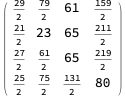

In [261]:
matrizC = (matrizA + matrizB) / 2;

Print["Matriz C (Promedio de manchas solares):"];
matrizC // MatrixForm

## 2

Matriz D (Diferencia promedio de manchas solares):


13     49            79
--     --            --
2      2      32     2

5                    103
-                    ---
2      6      35      2

  3      7           91
-(-)   -(-)          --
  2      2    27     2

5      19     55
-      --     --
2      2      2      26
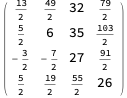

In [266]:
matrizD = (matrizA - matrizB) / 2;

Print["Matriz D (Diferencia promedio de manchas solares):"];
matrizD // MatrixForm

## 3

In [270]:
(* Pendiente de responder *)